In [1]:
# ============================================================
# CELL 1: Setup + Load all results
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

class Config:
    PROJECT_ROOT = '/content/drive/MyDrive/FinDocVQA'
    OUTPUTS_DIR  = os.path.join(PROJECT_ROOT, 'outputs')

cfg = Config()

# Load all result files from financial evaluation
results = {}
for fname, label in [
    ('final_pix2struct_results.json', 'Pix2Struct'),
    ('final_donut_results.json', 'Donut'),
    ('final_layoutlmv3_results.json', 'LayoutLMv3'),
    ('final_baseline_results.json', 'OCR+RoBERTa'),
    ('final_pix2struct_finetuned_results.json', 'Pix2Struct (LoRA)'),
]:
    path = os.path.join(cfg.OUTPUTS_DIR, fname)
    if os.path.exists(path):
        with open(path) as f:
            results[label] = json.load(f)
        print(f"✓ Loaded {label}: {len(results[label]['per_example'])} examples")
    else:
        print(f"✗ Missing: {fname}")

print(f"\n✓ Loaded {len(results)} model results")

Mounted at /content/drive
✓ Loaded Pix2Struct: 397 examples
✓ Loaded Donut: 397 examples
✓ Loaded LayoutLMv3: 397 examples
✓ Loaded OCR+RoBERTa: 397 examples
✓ Loaded Pix2Struct (LoRA): 397 examples

✓ Loaded 5 model results


In [2]:
# ============================================================
# CELL 2: Failure Mode Classification
# ============================================================
# For each wrong prediction, classify WHY it failed:
#   - VISUAL: model couldn't read the text/numbers from image
#   - STRUCTURAL: model found wrong row/column/cell
#   - NUMERICAL: model found right values but wrong computation
#   - LANGUAGE: model misunderstood the question or terminology
# ============================================================

def classify_failure(pred, gt, question, question_type):
    """Classify why a prediction failed."""
    pred_lower = pred.lower().strip()
    gt_lower = gt.lower().strip()

    if pred_lower == gt_lower:
        return 'correct'

    if not pred_lower:
        return 'visual'  # model produced nothing — couldn't read image

    # Numerical reasoning questions
    if question_type == 'numerical_reasoning':
        # Check if prediction contains any numbers
        pred_nums = ''.join(c for c in pred if c.isdigit() or c == '.')
        gt_nums = ''.join(c for c in gt if c.isdigit() or c == '.')
        if pred_nums and gt_nums:
            return 'numerical'  # found numbers but wrong calculation
        return 'visual'  # couldn't extract numbers at all

    # Layout questions
    if question_type == 'layout_understanding':
        if len(pred_lower) > 2 and any(c.isalpha() for c in pred_lower):
            return 'structural'  # found something but wrong position
        return 'visual'

    # Chart questions
    if question_type == 'chart_interpretation':
        if len(pred_lower) > 2:
            return 'visual'  # misread chart
        return 'visual'

    # Extractive questions
    if question_type == 'extractive':
        # Check if prediction is a number close to ground truth
        try:
            pred_val = float(pred.replace(',', '').replace('$', '').replace('(', '-').replace(')', ''))
            gt_val = float(gt.replace(',', '').replace('$', '').replace('(', '-').replace(')', ''))
            if abs(pred_val - gt_val) / max(abs(gt_val), 1) < 0.1:
                return 'structural'  # close but wrong cell
            else:
                return 'structural'  # found a number but from wrong location
        except ValueError:
            pass

        # Check if prediction shares words with ground truth
        pred_words = set(pred_lower.split())
        gt_words = set(gt_lower.split())
        if pred_words & gt_words:
            return 'language'  # partial understanding

        if len(pred_lower) > 3:
            return 'structural'  # found text but wrong location

        return 'visual'  # couldn't read properly

    return 'visual'

# --- Classify all failures for each model ---
print("Classifying failure modes...")
print("=" * 60)

model_failures = {}

for model_name, result in results.items():
    failures = {'visual': 0, 'structural': 0, 'numerical': 0, 'language': 0}
    correct = 0
    total = len(result['per_example'])

    failure_examples = []

    for ex in result['per_example']:
        pred = ex['prediction']
        gt = ex['ground_truth']
        qtype = ex['question_type']

        category = classify_failure(pred, gt, ex['question'], qtype)

        if category == 'correct':
            correct += 1
        else:
            failures[category] += 1
            failure_examples.append({
                'question': ex['question'],
                'ground_truth': gt,
                'prediction': pred,
                'question_type': qtype,
                'failure_mode': category,
            })

    model_failures[model_name] = {
        'failures': failures,
        'correct': correct,
        'total': total,
        'examples': failure_examples
    }

    print(f"\n  {model_name}:")
    print(f"    Correct: {correct}/{total} ({correct/total*100:.1f}%)")
    print(f"    Failures:")
    for mode, count in sorted(failures.items(), key=lambda x: -x[1]):
        if count > 0:
            print(f"      {mode:12s}: {count:3d} ({count/(total-correct)*100:.0f}% of errors)")

Classifying failure modes...

  Pix2Struct:
    Correct: 33/397 (8.3%)
    Failures:
      structural  : 223 (61% of errors)
      visual      :  73 (20% of errors)
      numerical   :  65 (18% of errors)
      language    :   3 (1% of errors)

  Donut:
    Correct: 22/397 (5.5%)
    Failures:
      structural  : 239 (64% of errors)
      visual      :  71 (19% of errors)
      numerical   :  63 (17% of errors)
      language    :   2 (1% of errors)

  LayoutLMv3:
    Correct: 41/397 (10.3%)
    Failures:
      structural  : 233 (65% of errors)
      numerical   :  60 (17% of errors)
      visual      :  49 (14% of errors)
      language    :  14 (4% of errors)

  OCR+RoBERTa:
    Correct: 29/397 (7.3%)
    Failures:
      structural  : 168 (46% of errors)
      visual      : 154 (42% of errors)
      numerical   :  25 (7% of errors)
      language    :  21 (6% of errors)

  Pix2Struct (LoRA):
    Correct: 12/397 (3.0%)
    Failures:
      structural  : 223 (58% of errors)
      visual

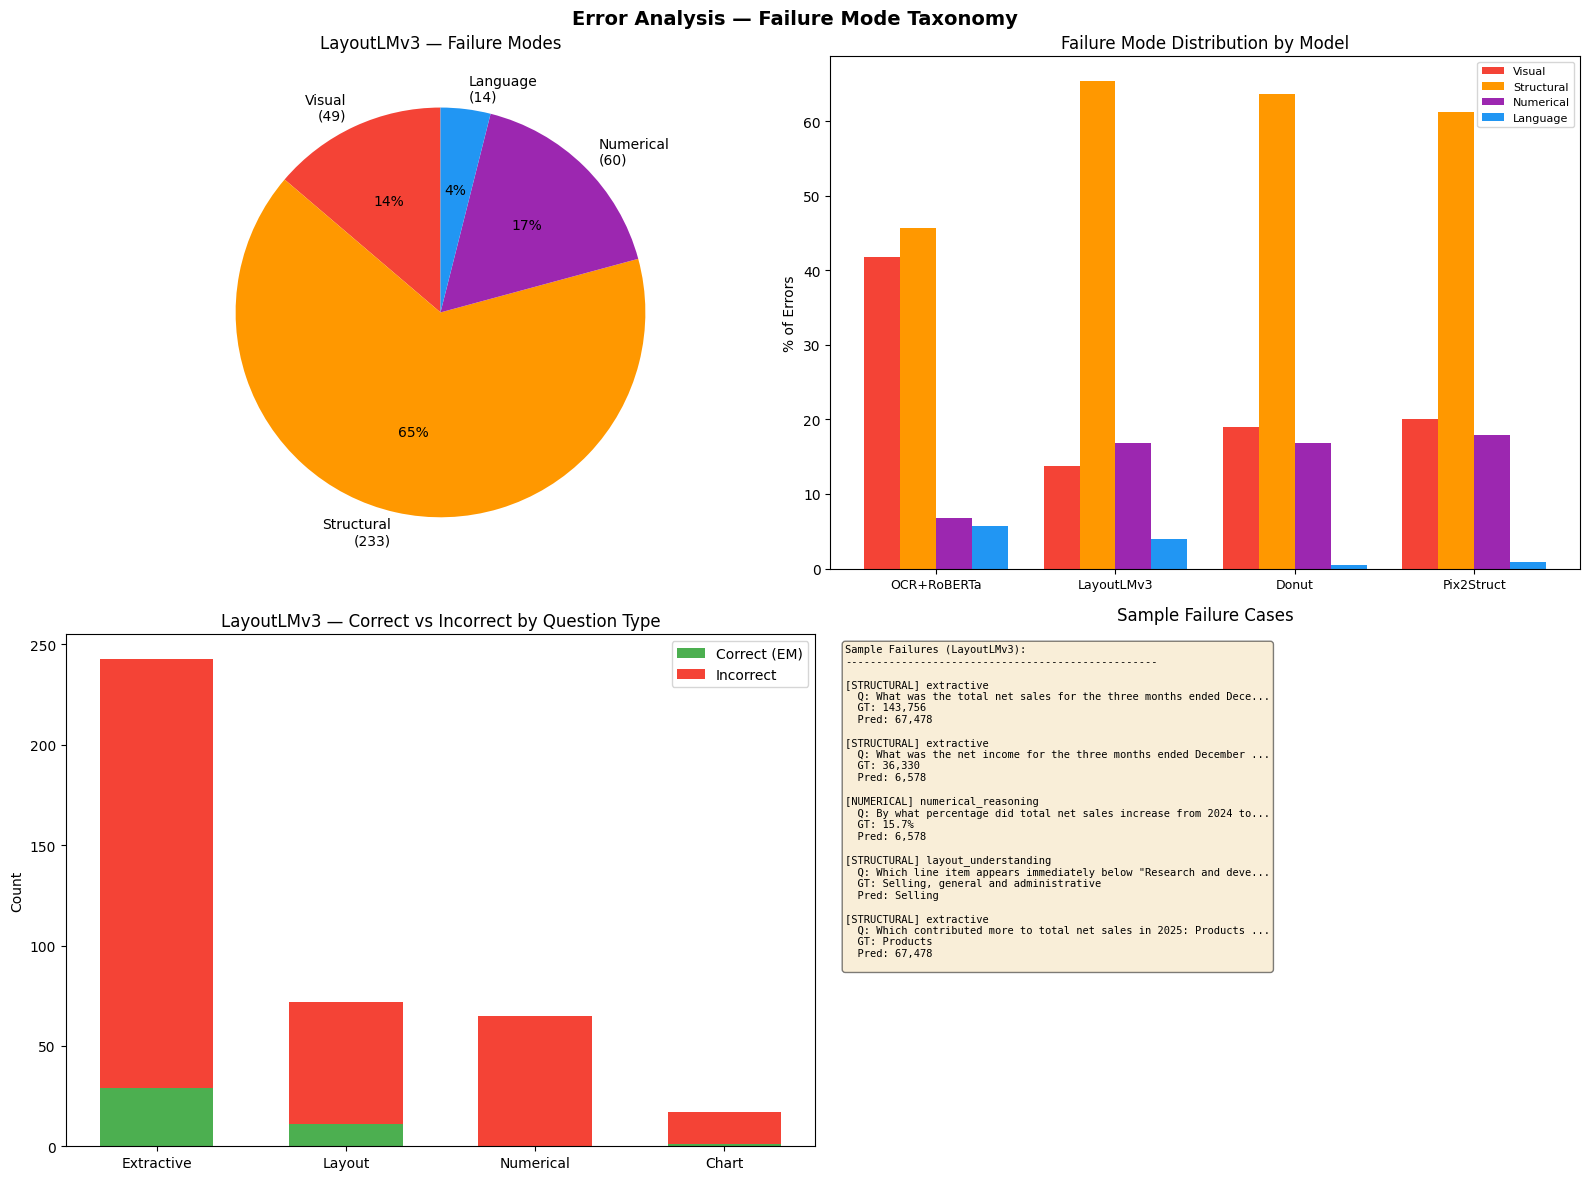

✓ Saved to outputs/error_analysis.png


In [3]:
# ============================================================
# CELL 3: Failure Mode Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Error Analysis — Failure Mode Taxonomy', fontsize=14, fontweight='bold')

# --- Plot 1: Failure mode distribution for best model (LayoutLMv3) ---
ax = axes[0, 0]
best_model = 'LayoutLMv3'
if best_model in model_failures:
    data = model_failures[best_model]
    modes = ['visual', 'structural', 'numerical', 'language']
    counts = [data['failures'][m] for m in modes]
    colors_pie = ['#F44336', '#FF9800', '#9C27B0', '#2196F3']
    labels = [f'{m.capitalize()}\n({c})' for m, c in zip(modes, counts) if c > 0]
    vals = [c for c in counts if c > 0]
    cols = [colors_pie[i] for i, c in enumerate(counts) if c > 0]
    ax.pie(vals, labels=labels, colors=cols, autopct='%1.0f%%', startangle=90, textprops={'fontsize': 10})
    ax.set_title(f'{best_model} — Failure Modes')

# --- Plot 2: All models failure comparison ---
ax = axes[0, 1]
model_names = ['OCR+RoBERTa', 'LayoutLMv3', 'Donut', 'Pix2Struct']
modes = ['visual', 'structural', 'numerical', 'language']
mode_colors = {'visual': '#F44336', 'structural': '#FF9800', 'numerical': '#9C27B0', 'language': '#2196F3'}

x = np.arange(len(model_names))
width = 0.2
for i, mode in enumerate(modes):
    vals = []
    for mn in model_names:
        if mn in model_failures:
            total_errors = sum(model_failures[mn]['failures'].values())
            if total_errors > 0:
                vals.append(model_failures[mn]['failures'][mode] / total_errors * 100)
            else:
                vals.append(0)
        else:
            vals.append(0)
    ax.bar(x + i*width, vals, width, label=mode.capitalize(), color=mode_colors[mode])

ax.set_ylabel('% of Errors')
ax.set_title('Failure Mode Distribution by Model')
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(model_names, fontsize=9)
ax.legend(fontsize=8)

# --- Plot 3: Correct vs incorrect by question type (LayoutLMv3) ---
ax = axes[1, 0]
if best_model in results:
    qtypes = ['extractive', 'layout_understanding', 'numerical_reasoning', 'chart_interpretation']
    qtype_labels = ['Extractive', 'Layout', 'Numerical', 'Chart']
    correct_by_type = []
    wrong_by_type = []

    for qt in qtypes:
        examples = [e for e in results[best_model]['per_example'] if e['question_type'] == qt]
        correct = sum(1 for e in examples if e['exact_match'] == 1.0)
        wrong = len(examples) - correct
        correct_by_type.append(correct)
        wrong_by_type.append(wrong)

    x = np.arange(len(qtype_labels))
    ax.bar(x, correct_by_type, 0.6, label='Correct (EM)', color='#4CAF50')
    ax.bar(x, wrong_by_type, 0.6, bottom=correct_by_type, label='Incorrect', color='#F44336')
    ax.set_ylabel('Count')
    ax.set_title(f'{best_model} — Correct vs Incorrect by Question Type')
    ax.set_xticks(x)
    ax.set_xticklabels(qtype_labels)
    ax.legend()

# --- Plot 4: Example failures ---
ax = axes[1, 1]
ax.axis('off')
if best_model in model_failures:
    examples = model_failures[best_model]['examples'][:6]
    text = "Sample Failures (LayoutLMv3):\n" + "-"*50 + "\n"
    for i, ex in enumerate(examples[:5]):
        q = ex['question'][:60] + "..." if len(ex['question']) > 60 else ex['question']
        text += f"\n[{ex['failure_mode'].upper()}] {ex['question_type']}\n"
        text += f"  Q: {q}\n"
        text += f"  GT: {ex['ground_truth'][:40]}\n"
        text += f"  Pred: {ex['prediction'][:40]}\n"
    ax.text(0.02, 0.98, text, transform=ax.transAxes, fontsize=7.5,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_title('Sample Failure Cases', pad=10)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'error_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/error_analysis.png")

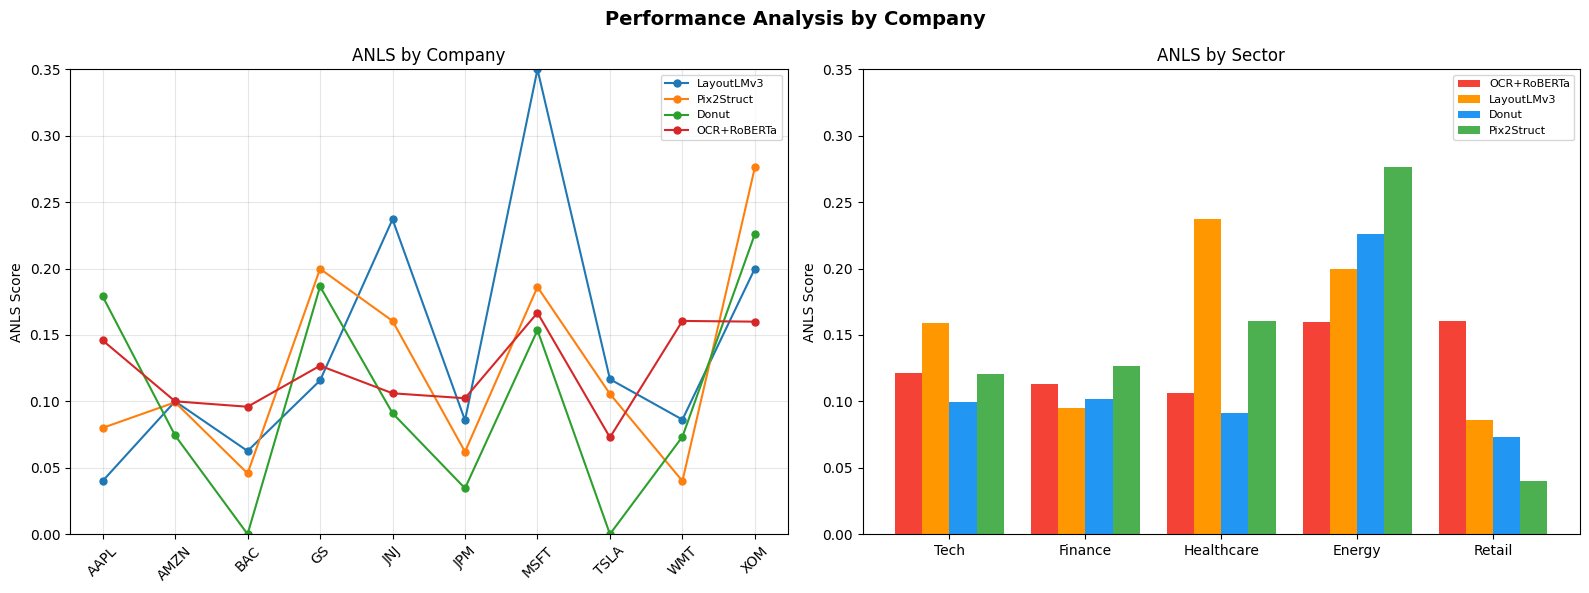

✓ Saved to outputs/company_analysis.png


In [4]:
# ============================================================
# CELL 4: Per-Company Performance Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Analysis by Company', fontsize=14, fontweight='bold')

# Get per-company ANLS for each model
companies = ['AAPL', 'AMZN', 'BAC', 'GS', 'JNJ', 'JPM', 'MSFT', 'TSLA', 'WMT', 'XOM']

ax = axes[0]
for model_name in ['LayoutLMv3', 'Pix2Struct', 'Donut', 'OCR+RoBERTa']:
    if model_name not in results:
        continue
    company_anls = []
    for ticker in companies:
        examples = [e for e in results[model_name]['per_example'] if e['ticker'] == ticker]
        if examples:
            avg = np.mean([e['anls'] for e in examples])
            company_anls.append(avg)
        else:
            company_anls.append(0)
    ax.plot(companies, company_anls, '-o', label=model_name, markersize=5)

ax.set_ylabel('ANLS Score')
ax.set_title('ANLS by Company')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 0.35)
ax.grid(True, alpha=0.3)

# Sector grouping
ax = axes[1]
sectors = {
    'Tech': ['AAPL', 'AMZN', 'MSFT', 'TSLA'],
    'Finance': ['BAC', 'GS', 'JPM'],
    'Healthcare': ['JNJ'],
    'Energy': ['XOM'],
    'Retail': ['WMT']
}

model_names = ['OCR+RoBERTa', 'LayoutLMv3', 'Donut', 'Pix2Struct']
colors = ['#F44336', '#FF9800', '#2196F3', '#4CAF50']
x = np.arange(len(sectors))
width = 0.2

for i, model_name in enumerate(model_names):
    if model_name not in results:
        continue
    sector_anls = []
    for sector, tickers in sectors.items():
        examples = [e for e in results[model_name]['per_example'] if e['ticker'] in tickers]
        if examples:
            sector_anls.append(np.mean([e['anls'] for e in examples]))
        else:
            sector_anls.append(0)
    ax.bar(x + i*width, sector_anls, width, label=model_name, color=colors[i])

ax.set_ylabel('ANLS Score')
ax.set_title('ANLS by Sector')
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(list(sectors.keys()))
ax.legend(fontsize=8)
ax.set_ylim(0, 0.35)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'company_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to outputs/company_analysis.png")